---
title: "Lecture 3 – Neural Networks"
subtitle: "ML – Missing Semester CUET"
format:
  html:
    code-fold: false
---

## From Logistic Regression to Neural Networks

A single neuron **is** logistic regression: $a = \sigma(w^T x + b)$.

Stack many neurons in **layers** and you get a neural network that can learn non-linear decision boundaries.

```
Input  →  Hidden layer(s)  →  Output
 x          a = g(Wx+b)        ŷ
```

---

## Activation Functions

| Function | Formula | Use case |
|----------|---------|----------|
| **Sigmoid** | $\frac{1}{1+e^{-z}}$ | Output layer (binary) |
| **ReLU** | $\max(0, z)$ | Hidden layers (default) |
| **Softmax** | $\frac{e^{z_k}}{\sum_j e^{z_j}}$ | Output layer (multi-class) |

ReLU avoids the **vanishing gradient** problem that plagues sigmoid in deep nets.

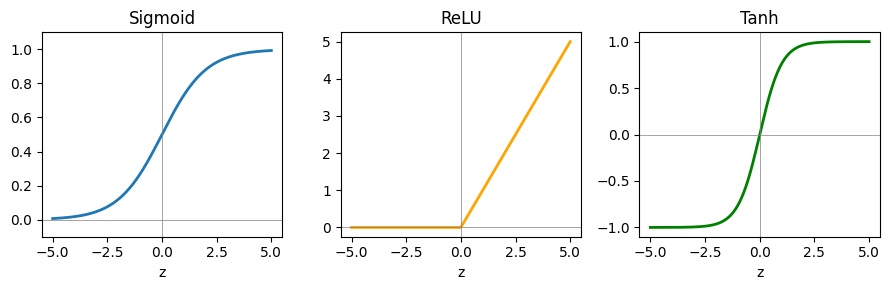

In [1]:
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

# Sigmoid
axes[0].plot(z, 1/(1+np.exp(-z)), linewidth=2)
axes[0].set_title('Sigmoid'); axes[0].set_ylim(-0.1, 1.1)

# ReLU
axes[1].plot(z, np.maximum(0, z), linewidth=2, color='orange')
axes[1].set_title('ReLU')

# Tanh
axes[2].plot(z, np.tanh(z), linewidth=2, color='green')
axes[2].set_title('Tanh'); axes[2].set_ylim(-1.1, 1.1)

for ax in axes:
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel('z')
plt.tight_layout(); plt.show()

---

## Forward Propagation

For a two-layer network (one hidden layer):

$$z^{[1]} = W^{[1]}x + b^{[1]}, \quad a^{[1]} = \text{ReLU}(z^{[1]})$$
$$z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}, \quad \hat{y} = \text{softmax}(z^{[2]})$$

Each layer transforms the representation — the network learns progressively more abstract features.

---

## Backpropagation — The Chain Rule at Scale

To compute $\frac{\partial J}{\partial W^{[1]}}$, we apply the chain rule **backwards** through the graph:

$$\delta^{[2]} = \hat{y} - y$$
$$\delta^{[1]} = (W^{[2]T} \delta^{[2]}) \odot g'(z^{[1]})$$

Then:

$$\frac{\partial J}{\partial W^{[l]}} = \frac{1}{m}\delta^{[l]} a^{[l-1]T}$$

This is computed **once per forward pass** — efficient!

In [2]:
# Minimal 2-layer neural network on a toy dataset
np.random.seed(1)

# Spiral dataset (2 classes)
N = 150  # points per class
D = 2    # features
K = 2    # classes
X = np.zeros((N*K, D))
y = np.zeros(N*K, dtype=int)
for j in range(K):
    ix = range(N*j, N*(j+1))
    r = np.linspace(0.0, 1, N)
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.25
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j

# One-hot encode
Y = np.eye(K)[y]  # (300, 2)

# Network: 2 → 64 (ReLU) → 2 (softmax)
h_size = 64
W1 = 0.01 * np.random.randn(D, h_size)
b1 = np.zeros((1, h_size))
W2 = 0.01 * np.random.randn(h_size, K)
b2 = np.zeros((1, K))
lr = 1.0
m = X.shape[0]

for epoch in range(500):
    # Forward
    z1 = X @ W1 + b1
    a1 = np.maximum(0, z1)  # ReLU
    z2 = a1 @ W2 + b2
    exp_z2 = np.exp(z2 - np.max(z2, axis=1, keepdims=True))
    probs = exp_z2 / exp_z2.sum(axis=1, keepdims=True)  # softmax

    # Loss
    loss = -np.sum(Y * np.log(probs + 1e-8)) / m
    if epoch % 100 == 0:
        print(f"Epoch {epoch:3d} — loss: {loss:.4f}")

    # Backward
    dz2 = (probs - Y) / m
    dW2 = a1.T @ dz2
    db2 = dz2.sum(axis=0, keepdims=True)
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)  # ReLU grad
    dW1 = X.T @ dz1
    db1 = dz1.sum(axis=0, keepdims=True)

    W2 -= lr * dW2; b2 -= lr * db2
    W1 -= lr * dW1; b1 -= lr * db1

predicted = np.argmax(probs, axis=1)
acc = np.mean(predicted == y)
print(f"Final training accuracy: {acc*100:.1f}%")

Epoch   0 — loss: 0.6931
Epoch 100 — loss: 0.3799
Epoch 200 — loss: 0.2069
Epoch 300 — loss: 0.1881
Epoch 400 — loss: 0.1799
Final training accuracy: 93.0%


---

## Key Takeaways

1. A neural network is layers of parameterised, non-linear transformations.
2. **Forward pass** computes predictions; **backward pass** computes gradients.
3. ReLU is the default hidden-layer activation; softmax for multi-class output.
4. Backpropagation is just the chain rule applied systematically.
5. Even a simple 2-layer net can learn complex, non-linear boundaries.

**Congratulations** — you've completed the ML foundations module! 🎉